# NB04: Functional Context of AMR Genes

**Goal**: Test H3 and H5 — what functional annotations co-occur with AMR genes? Are AMR genes enriched in specific COG categories? How many are "AMR-only" (detected by AMRFinderPlus but lacking other functional annotations)?

**Depends on**: NB01 outputs + Spark session for COG baseline comparison

**Outputs**:
- `../data/amr_cog_enrichment.csv` — COG enrichment analysis
- `../data/amr_annotation_tiers.csv` — annotation depth classification
- `../figures/amr_functional_*.png`

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

try:
    spark = get_spark_session()
except NameError:
    sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', '..', 'scripts'))
    from get_spark_session import get_spark_session
    spark = get_spark_session()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'savefig.bbox': 'tight', 'savefig.dpi': 150,
})

amr = pd.read_csv(DATA_DIR / 'amr_census.csv')
print(f"Loaded {len(amr):,} AMR clusters")

Loaded 83,008 AMR clusters


## 1. COG Enrichment Analysis

Compare COG category distribution of AMR genes vs the pangenome-wide baseline. Need to get baseline COG distribution from eggNOG for a representative sample.

In [2]:
# Get COG category distribution for AMR clusters (via eggNOG)
# Use chunked IN clause (createDataFrame has version mismatch)
amr_ids = amr['gene_cluster_id'].unique().tolist()

def chunked_query(spark, ids, query_template, chunk_size=5000):
    results = []
    for i in range(0, len(ids), chunk_size):
        chunk = ids[i:i+chunk_size]
        id_list = "','".join(chunk)
        query = query_template.format(id_list=f"'{id_list}'")
        results.append(spark.sql(query).toPandas())
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

# AMR COG distribution — aggregate per chunk then re-aggregate
amr_cog_raw = chunked_query(spark, amr_ids, """
    SELECT COG_category, COUNT(*) as amr_count
    FROM kbase_ke_pangenome.eggnog_mapper_annotations
    WHERE query_name IN ({id_list})
      AND COG_category IS NOT NULL AND COG_category != '' AND COG_category != '-'
    GROUP BY COG_category
""")
amr_cog = amr_cog_raw.groupby('COG_category')['amr_count'].sum().reset_index()

# Baseline: overall COG distribution from eggNOG (93M rows — aggregate in Spark, no filter)
baseline_cog = spark.sql("""
    SELECT COG_category, COUNT(*) as baseline_count
    FROM kbase_ke_pangenome.eggnog_mapper_annotations
    WHERE COG_category IS NOT NULL AND COG_category != '' AND COG_category != '-'
    GROUP BY COG_category
""").toPandas()

print(f"AMR clusters with COG annotation: {amr_cog['amr_count'].sum():,}")
print(f"Baseline clusters with COG annotation: {baseline_cog['baseline_count'].sum():,}")

AMR clusters with COG annotation: 76,832
Baseline clusters with COG annotation: 85,986,308


In [3]:
# COG category names
COG_NAMES = {
    'J': 'Translation', 'A': 'RNA processing', 'K': 'Transcription',
    'L': 'Replication/repair', 'B': 'Chromatin', 'D': 'Cell cycle',
    'Y': 'Nuclear structure', 'V': 'Defense mechanisms', 'T': 'Signal transduction',
    'M': 'Cell wall/membrane', 'N': 'Cell motility', 'Z': 'Cytoskeleton',
    'W': 'Extracellular structures', 'U': 'Secretion', 'O': 'Post-translational',
    'X': 'Mobilome', 'C': 'Energy production', 'G': 'Carbohydrate metabolism',
    'E': 'Amino acid metabolism', 'F': 'Nucleotide metabolism',
    'H': 'Coenzyme metabolism', 'I': 'Lipid metabolism',
    'P': 'Inorganic ion transport', 'Q': 'Secondary metabolites',
    'R': 'General function', 'S': 'Function unknown'
}

# Expand multi-letter COG categories (e.g., "EG" → "E" and "G")
def expand_cog(df, count_col):
    expanded = []
    for _, row in df.iterrows():
        cats = str(row['COG_category'])
        for c in cats:
            if c in COG_NAMES:
                expanded.append({'COG': c, 'count': row[count_col]})
    return pd.DataFrame(expanded).groupby('COG')['count'].sum().reset_index()

amr_cog_exp = expand_cog(amr_cog, 'amr_count')
base_cog_exp = expand_cog(baseline_cog, 'baseline_count')

# Merge and compute enrichment
cog_merged = amr_cog_exp.merge(base_cog_exp, on='COG', suffixes=('_amr', '_baseline'))
cog_merged['amr_frac'] = cog_merged['count_amr'] / cog_merged['count_amr'].sum()
cog_merged['base_frac'] = cog_merged['count_baseline'] / cog_merged['count_baseline'].sum()
cog_merged['enrichment'] = (cog_merged['amr_frac'] / cog_merged['base_frac']).round(2)
cog_merged['name'] = cog_merged['COG'].map(COG_NAMES)
cog_merged = cog_merged.sort_values('enrichment', ascending=False)

print("=== COG Category Enrichment in AMR Genes vs Pangenome Baseline ===\n")
print(f"{'COG':<4} {'Name':<30} {'AMR %':>7} {'Base %':>7} {'Enrich':>8} {'AMR n':>8}")
print("-" * 70)
for _, row in cog_merged.iterrows():
    print(f"{row['COG']:<4} {row['name']:<30} {row['amr_frac']*100:>6.1f}% {row['base_frac']*100:>6.1f}% "
          f"{row['enrichment']:>7.2f}x {int(row['count_amr']):>8,}")

cog_merged.to_csv(DATA_DIR / 'amr_cog_enrichment.csv', index=False)

=== COG Category Enrichment in AMR Genes vs Pangenome Baseline ===

COG  Name                             AMR %  Base %   Enrich    AMR n
----------------------------------------------------------------------
V    Defense mechanisms               14.9%    2.1%    7.05x   13,145
P    Inorganic ion transport          10.7%    5.6%    1.93x    9,483
J    Translation                       8.4%    5.6%    1.50x    7,420
H    Coenzyme metabolism               5.6%    4.0%    1.39x    4,924
C    Energy production                 6.4%    6.4%    0.99x    5,627
G    Carbohydrate metabolism           5.8%    6.1%    0.95x    5,133
E    Amino acid metabolism             7.5%    7.9%    0.95x    6,660
S    Function unknown                 18.5%   19.8%    0.94x   16,369
T    Signal transduction               4.0%    4.3%    0.93x    3,535
K    Transcription                     7.1%    7.6%    0.93x    6,252
M    Cell wall/membrane                5.8%    6.2%    0.93x    5,095
F    Nucleotide metab

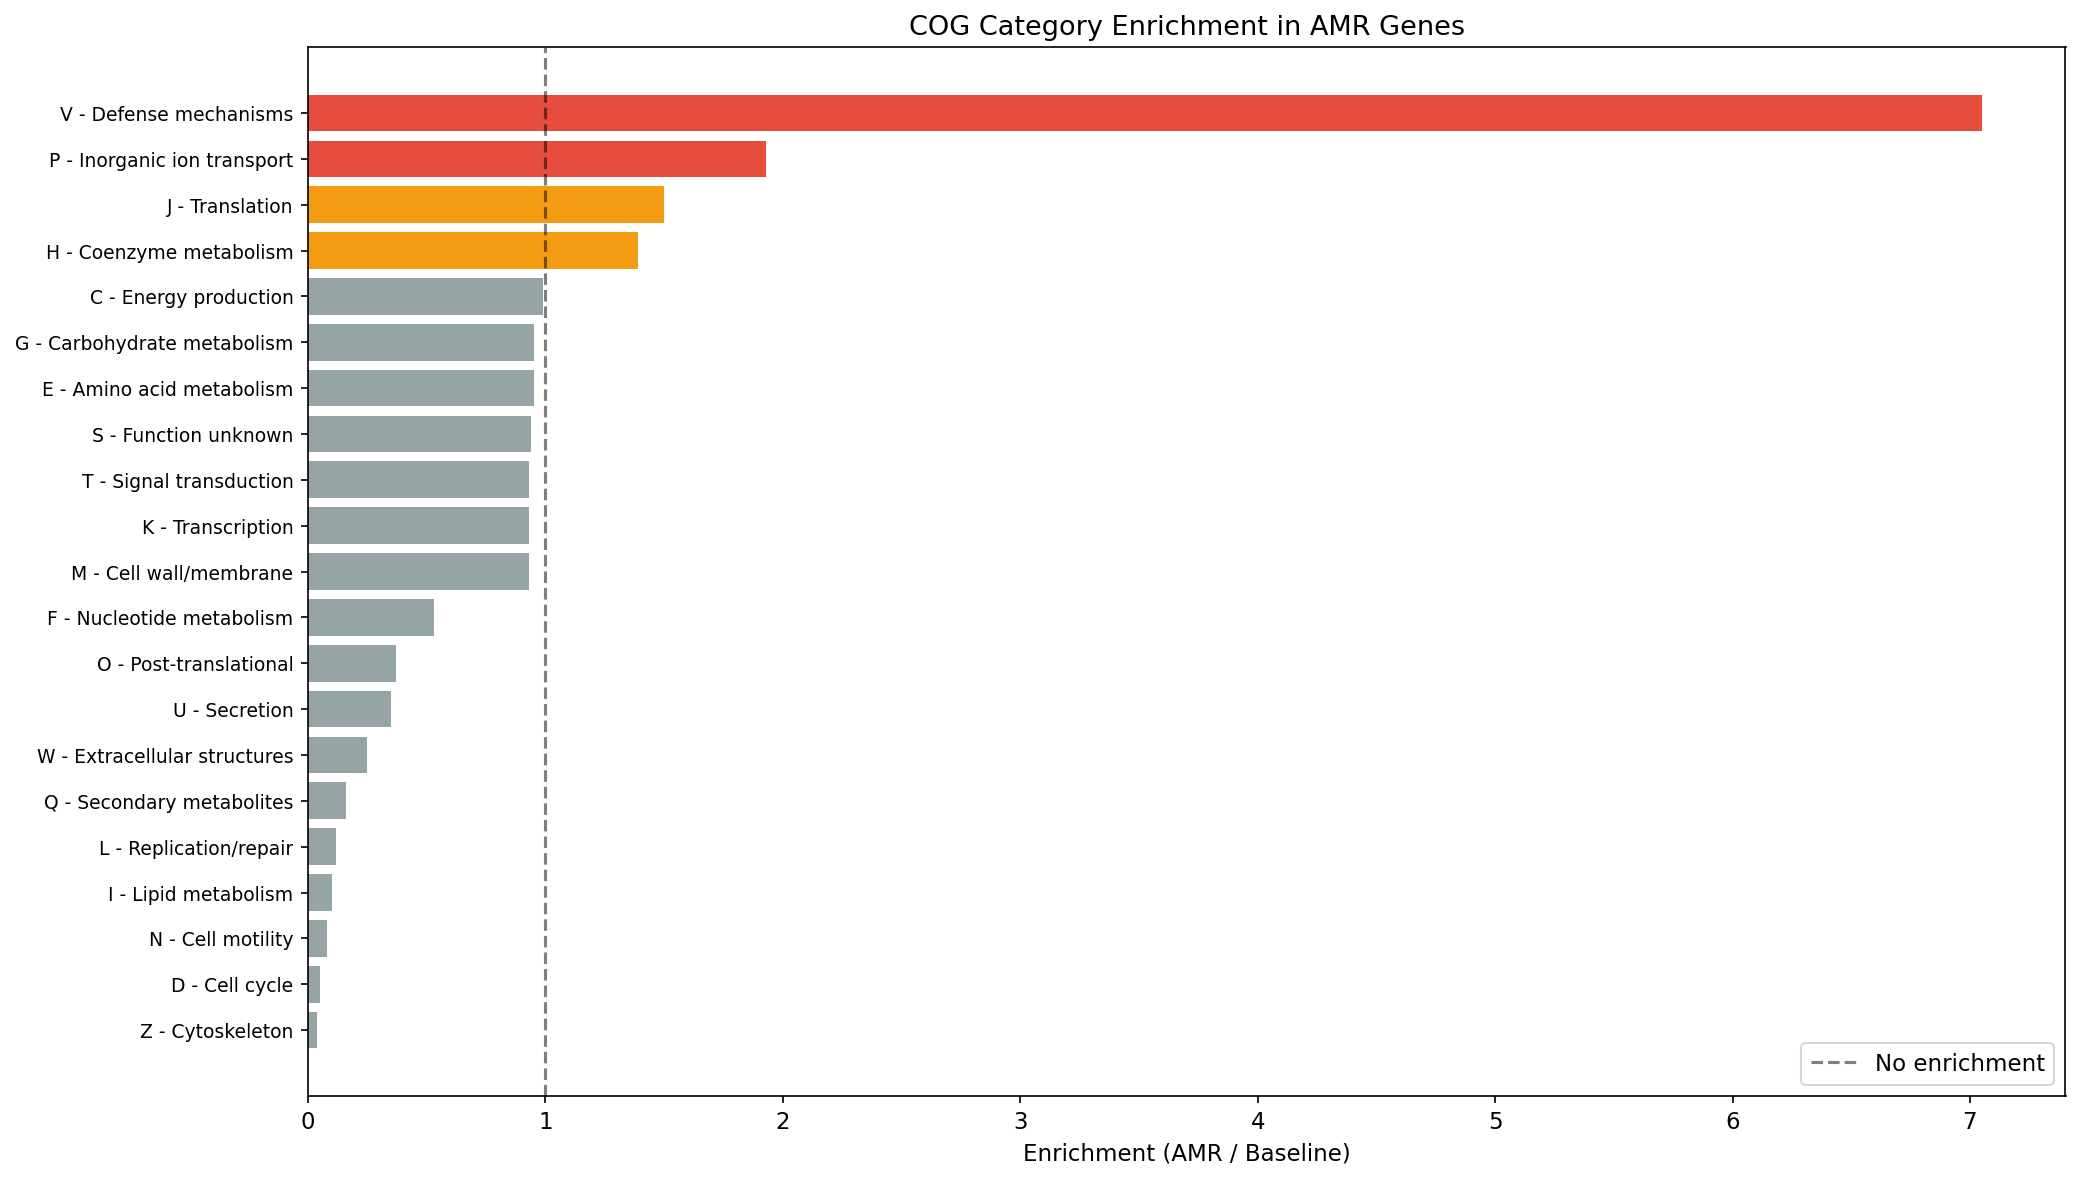

In [4]:
# COG enrichment visualization
fig, ax = plt.subplots(figsize=(14, 8))

cog_plot = cog_merged.sort_values('enrichment')
colors = ['#e74c3c' if e > 1.5 else '#f39c12' if e > 1 else '#95a5a6'
          for e in cog_plot['enrichment']]

ax.barh(range(len(cog_plot)), cog_plot['enrichment'], color=colors)
ax.set_yticks(range(len(cog_plot)))
ax.set_yticklabels([f"{row['COG']} - {row['name']}" for _, row in cog_plot.iterrows()], fontsize=9)
ax.axvline(1.0, color='black', linestyle='--', alpha=0.5, label='No enrichment')
ax.set_xlabel('Enrichment (AMR / Baseline)')
ax.set_title('COG Category Enrichment in AMR Genes')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'amr_cog_enrichment.png')
plt.show()

## 2. Annotation Depth: "AMR-only" Dark Matter

Characterize AMR clusters by annotation depth. The "AMR-only" clusters (AMRFinderPlus hit but no other functional annotation) are particularly interesting — they may represent novel resistance mechanisms.

In [5]:
# Annotation depth from NB01 census
if 'n_sources' not in amr.columns:
    print("Warning: n_sources not in census data — NB01 may need to be re-run")
else:
    # Annotation tier classification
    amr['anno_tier'] = amr['n_sources'].map({
        0: 'AMR-only (no other annotation)',
        1: 'Sparse (1 source)',
        2: 'Moderate (2 sources)',
        3: 'Well-annotated (3 sources)'
    })
    
    print("=== AMR Cluster Annotation Depth ===\n")
    tier_counts = amr['anno_tier'].value_counts()
    for tier, count in tier_counts.items():
        print(f"  {tier}: {count:,} ({count/len(amr)*100:.1f}%)")
    
    # Conservation by annotation depth
    print("\n=== Conservation by Annotation Depth ===")
    if 'conservation_class' not in amr.columns:
        amr['conservation_class'] = np.where(
            amr['is_core'], 'Core',
            np.where(amr['is_singleton'], 'Singleton', 'Auxiliary')
        )
    
    for tier in sorted(amr['anno_tier'].unique()):
        sub = amr[amr['anno_tier'] == tier]
        pct_core = (sub['conservation_class'] == 'Core').mean() * 100
        pct_sing = (sub['conservation_class'] == 'Singleton').mean() * 100
        print(f"  {tier}: {pct_core:.1f}% core, {pct_sing:.1f}% singleton (n={len(sub):,})")

    # Are AMR-only clusters more likely to be singletons?
    amr_only = amr[amr['n_sources'] == 0]
    amr_annotated = amr[amr['n_sources'] > 0]
    
    only_sing = (amr_only['conservation_class'] == 'Singleton').mean()
    annot_sing = (amr_annotated['conservation_class'] == 'Singleton').mean()
    
    print(f"\nSingleton rate: AMR-only={only_sing*100:.1f}% vs annotated={annot_sing*100:.1f}%")
    
    # Fisher's exact test
    table = np.array([
        [(amr_only['conservation_class'] == 'Singleton').sum(), (amr_only['conservation_class'] != 'Singleton').sum()],
        [(amr_annotated['conservation_class'] == 'Singleton').sum(), (amr_annotated['conservation_class'] != 'Singleton').sum()]
    ])
    odds, p_fisher = stats.fisher_exact(table)
    print(f"Fisher's exact: OR={odds:.2f}, p={p_fisher:.2e}")

=== AMR Cluster Annotation Depth ===

  Moderate (2 sources): 77,232 (93.0%)
  Sparse (1 source): 5,776 (7.0%)

=== Conservation by Annotation Depth ===
  Moderate (2 sources): 32.0% core, 34.6% singleton (n=77,232)
  Sparse (1 source): 7.3% core, 55.4% singleton (n=5,776)

Singleton rate: AMR-only=nan% vs annotated=36.1%
Fisher's exact: OR=nan, p=1.00e+00
